In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Vikram Bhagnani\OneDrive\Desktop\Internship project\Client Project\Customer Segmentation1.csv")
df.head()

,CustomerID,Age,Gender,ItemPurchased,Category,PurchaseAmountUSD,Location,Size,Color,Season,ReviewRating,SubscriptionStatus,ShippingType,DiscountApplied,PromoCodeUsed,PreviousPurchases,PaymentMethod,FrequencyOfPurchases
0,1,56,Male,Bag,Accessories,374.86,New York,L,Red,Fall,3,No,Standard,Yes,No,7,PayPal,Fortnightly
1,2,46,Male,Shoes,Home Decor,33.28,Los Angeles,S,Black,Spring,2,No,Express,Yes,No,3,UPI,Weekly
2,3,32,Female,Laptop,Home Decor,117.45,Houston,S,Black,Fall,4,No,Standard,Yes,Yes,13,UPI,Monthly
3,4,60,Male,Bag,Home Decor,356.05,Chicago,M,Green,Summer,2,Yes,Express,No,No,14,PayPal,Weekly
4,5,25,Female,Laptop,Accessories,393.50,Houston,M,Black,Winter,2,Yes,Express,No,No,5,Cash,Fortnightly


In [2]:
df.info() #it gives the  details of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            3900 non-null   int64  
 1   Age                   3900 non-null   int64  
 2   Gender                3900 non-null   object 
 3   ItemPurchased         3900 non-null   object 
 4   Category              3900 non-null   object 
 5   PurchaseAmountUSD     3900 non-null   float64
 6   Location              3900 non-null   object 
 7   Size                  3900 non-null   object 
 8   Color                 3900 non-null   object 
 9   Season                3900 non-null   object 
 10  ReviewRating          3900 non-null   int64  
 11  SubscriptionStatus    3900 non-null   object 
 12  ShippingType          3900 non-null   object 
 13  DiscountApplied       3900 non-null   object 
 14  PromoCodeUsed         3900 non-null   object 
 15  PreviousPurchases    

In [5]:
# to identify whether we have unrealistic vlues or outliers in any of the column 
df.describe().round(2)

,CustomerID,Age,PurchaseAmountUSD,ReviewRating,PreviousPurchases
count,3900.00,3900.0,3900.00,3900.00,3900.00
mean,1950.50,41.2,255.48,3.03,6.94
std,1125.98,13.5,142.15,1.41,4.31
min,1.00,18.0,10.08,1.00,0.00
25%,975.75,30.0,131.88,2.00,3.00
50%,1950.50,41.0,254.52,3.00,7.00
75%,2925.25,53.0,380.74,4.00,11.00
max,3900.00,64.0,499.84,5.00,14.00


In [6]:
df.isnull().sum() # to check the null values in the column

CustomerID              0
Age                     0
Gender                  0
ItemPurchased           0
Category                0
PurchaseAmountUSD       0
Location                0
Size                    0
Color                   0
Season                  0
ReviewRating            0
SubscriptionStatus      0
ShippingType            0
DiscountApplied         0
PromoCodeUsed           0
PreviousPurchases       0
PaymentMethod           0
FrequencyOfPurchases    0
dtype: int64

In [7]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [8]:
df["Season"].unique()

array(['Fall', 'Spring', 'Summer', 'Winter'], dtype=object)

In [9]:
df["PaymentMethod"].unique()

array(['PayPal', 'UPI', 'Cash', 'Credit Card', 'Debit Card'], dtype=object)

In [3]:
df["Category"].unique()

array(['Accessories', 'Home Decor', 'Clothing', 'Electronics', 'Sports'],
      dtype=object)

#  Revenue by Category

In [5]:
# Category vise total revenue!

category_revenue = df.groupby("Category")["PurchaseAmountUSD"].sum().sort_values(ascending=False)
category_revenue

Category
Clothing       208775.03
Accessories    208063.00
Home Decor     196999.83
Electronics    193682.52
Sports         188858.42
Name: PurchaseAmountUSD, dtype: float64

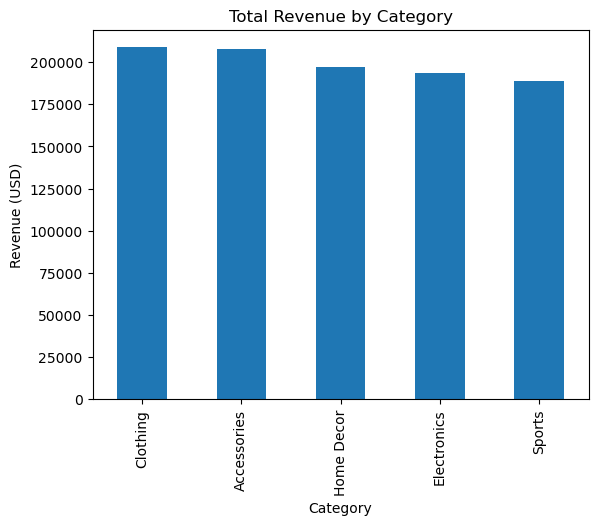

In [6]:

import matplotlib.pyplot as plt

category_revenue.plot(kind="bar")
plt.title("Total Revenue by Category")
plt.ylabel("Revenue (USD)")
plt.show()

In [13]:
# Category vise average revenue!

category_avg = df.groupby("Category")["PurchaseAmountUSD"].mean().sort_values(ascending=False).round(2)
category_avg

Category
Clothing       262.28
Home Decor     259.21
Accessories    253.74
Sports         251.14
Electronics    250.88
Name: PurchaseAmountUSD, dtype: float64

In [7]:
# Number of transaction per catogory
category_count = df["Category"].value_counts()
category_count

Category
Accessories    820
Clothing       796
Electronics    772
Home Decor     760
Sports         752
Name: count, dtype: int64

# DISCOUNT IMPACT ANALYSIS

In [15]:
discount_analysis = df.groupby(["Category", "DiscountApplied"])["PurchaseAmountUSD"].mean()

discount_analysis

Category     DiscountApplied
Accessories  No                 255.475743
             Yes                252.045192
Clothing     No                 254.416459
             Yes                270.976058
Electronics  No                 252.433780
             Yes                249.128923
Home Decor   No                 265.285354
             Yes                253.103193
Sports       No                 252.048974
             Yes                250.163867
Name: PurchaseAmountUSD, dtype: float64

In [8]:
discount_count = df.groupby(["Category", "DiscountApplied"]).size()

discount_count

Category     DiscountApplied
Accessories  No                 404
             Yes                416
Clothing     No                 418
             Yes                378
Electronics  No                 410
             Yes                362
Home Decor   No                 381
             Yes                379
Sports       No                 390
             Yes                362
dtype: int64

# Age vs Spending Behavio

Which age group spends most?

Which age group is discount sensitive?

Which age group is high-value target?

In [9]:
#Which age group spends highest on average?
df["AgeGroup"] = pd.cut(df["Age"],
                        bins=[18,25,35,45,60,100],
                        labels=["18-25","26-35","36-45","46-60","60+"])

age_spending = df.groupby("AgeGroup")["PurchaseAmountUSD"].mean()

age_spending


C:\Users\Vikram Bhagnani\AppData\Local\Temp\ipykernel_4708\3646053416.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = df.groupby("AgeGroup")["PurchaseAmountUSD"].mean()


AgeGroup
18-25    258.044283
26-35    253.976324
36-45    260.391814
46-60    250.954750
60+      257.996912
Name: PurchaseAmountUSD, dtype: float64

In [10]:
#Total Revenue by Age Group
age_revenue = df.groupby("AgeGroup")["PurchaseAmountUSD"].sum()

age_revenue

C:\Users\Vikram Bhagnani\AppData\Local\Temp\ipykernel_4708\2974779038.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_revenue = df.groupby("AgeGroup")["PurchaseAmountUSD"].sum()


AgeGroup
18-25    147601.33
26-35    202419.13
36-45    223936.96
46-60    311183.89
60+       91072.91
Name: PurchaseAmountUSD, dtype: float64

In [9]:
#Category Preference by Age Group
age_category = df.groupby(["AgeGroup", "Category"])["PurchaseAmountUSD"].sum()

age_category

C:\Users\Vikram Bhagnani\AppData\Local\Temp\ipykernel_10544\1225294275.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_category = df.groupby(["AgeGroup", "Category"])["PurchaseAmountUSD"].sum()


AgeGroup  Category   
18-25     Accessories    27047.20
          Clothing       30164.97
          Electronics    32816.02
          Home Decor     33422.88
          Sports         24150.26
26-35     Accessories    38896.32
          Clothing       45730.37
          Electronics    39137.75
          Home Decor     33137.57
          Sports         45517.12
36-45     Accessories    46543.39
          Clothing       46314.91
          Electronics    46719.00
          Home Decor     45782.34
          Sports         38577.32
46-60     Accessories    72557.71
          Clothing       63559.69
          Electronics    54688.78
          Home Decor     59500.78
          Sports         60876.93
60+       Accessories    19615.18
          Clothing       18494.20
          Electronics    17417.59
          Home Decor     19525.40
          Sports         16020.54
Name: PurchaseAmountUSD, dtype: float64

In [10]:
# Spending by Age + Payment Method
age_payment_spending = df.groupby(["AgeGroup", "PaymentMethod"])["PurchaseAmountUSD"].sum()

age_payment_spending

C:\Users\Vikram Bhagnani\AppData\Local\Temp\ipykernel_10544\4223439065.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_payment_spending = df.groupby(["AgeGroup", "PaymentMethod"])["PurchaseAmountUSD"].sum()


AgeGroup  PaymentMethod
18-25     Cash             26071.33
          Credit Card      32184.46
          Debit Card       29665.41
          PayPal           29534.93
          UPI              30145.20
26-35     Cash             39088.91
          Credit Card      41640.74
          Debit Card       40180.72
          PayPal           34481.20
          UPI              47027.56
36-45     Cash             47127.29
          Credit Card      45719.81
          Debit Card       42802.86
          PayPal           51854.30
          UPI              36432.70
46-60     Cash             59604.95
          Credit Card      65484.28
          Debit Card       61524.85
          PayPal           58975.28
          UPI              65594.53
60+       Cash             18827.57
          Credit Card      19628.58
          Debit Card       18457.85
          PayPal           18079.93
          UPI              16078.98
Name: PurchaseAmountUSD, dtype: float64

In [11]:
#Seasonal Impact
season_revenue = df.groupby("Season")["PurchaseAmountUSD"].sum()

season_revenue

Season
Fall      253958.19
Spring    271934.63
Summer    227141.03
Winter    243344.95
Name: PurchaseAmountUSD, dtype: float64

In [12]:
#Location Impact
location_revenue = df.groupby("Location")["PurchaseAmountUSD"].sum().sort_values(ascending=False)

location_revenue.head()

Location
Chicago        205405.71
New York       205032.64
Los Angeles    202583.83
Miami          193080.46
Houston        190276.16
Name: PurchaseAmountUSD, dtype: float64

# ~CUSTOMER CLUSTERING

In [11]:
customer_df = df.groupby("CustomerID").agg({
    "Age": "first",
    "PurchaseAmountUSD": "sum",
    "PreviousPurchases": "max",
    "ReviewRating": "mean",
    "SubscriptionStatus": "first"
}).reset_index()

customer_df.head()

,CustomerID,Age,PurchaseAmountUSD,PreviousPurchases,ReviewRating,SubscriptionStatus
0,1,56,374.86,7,3.0,No
1,2,46,33.28,3,2.0,No
2,3,32,117.45,13,4.0,No
3,4,60,356.05,14,2.0,Yes
4,5,25,393.50,5,2.0,Yes


In [12]:
#Check Row Count
customer_df.shape

(3900, 6)

In [18]:
#Convert SubscriptionStatus
customer_df["SubscriptionStatus"] = customer_df["SubscriptionStatus"].map({"Yes":1, "No":0})

In [38]:
#Select Features for Clustering
X = customer_df.drop("CustomerID", axis=1)

In [39]:
#Scale Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
customer_df["SubscriptionStatus"] = customer_df["SubscriptionStatus"].map({"Yes":1, "No":0})

In [19]:
customer_df = df.groupby("CustomerID").agg({
    "Age": "first",
    "PurchaseAmountUSD": "sum",
    "PreviousPurchases": "max",
    "ReviewRating": "mean",
    "SubscriptionStatus": "first"
}).reset_index()

In [20]:
customer_df["SubscriptionStatus"].unique()

array(['No', 'Yes'], dtype=object)

In [21]:
customer_df["SubscriptionStatus"] = customer_df["SubscriptionStatus"].astype(str).str.strip()

In [22]:
customer_df["SubscriptionStatus"].unique()

array(['No', 'Yes'], dtype=object)

In [23]:
customer_df["SubscriptionStatus"] = customer_df["SubscriptionStatus"].map({
    "Yes": 1,
    "No": 0
})

In [24]:
customer_df.isnull().sum()

CustomerID            0
Age                   0
PurchaseAmountUSD     0
PreviousPurchases     0
ReviewRating          0
SubscriptionStatus    0
dtype: int64

In [25]:
X = customer_df.drop("CustomerID", axis=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
X = customer_df.drop("CustomerID", axis=1)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

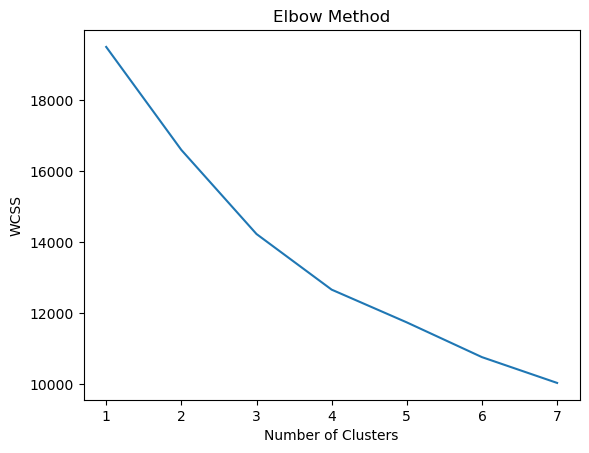

In [29]:
#Find Optimal Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 8), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [30]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

customer_df.head()

,CustomerID,Age,PurchaseAmountUSD,PreviousPurchases,ReviewRating,SubscriptionStatus,Cluster
0,1,56,374.86,7,3.0,0,0
1,2,46,33.28,3,2.0,0,0
2,3,32,117.45,13,4.0,0,1
3,4,60,356.05,14,2.0,1,2
4,5,25,393.50,5,2.0,1,2


In [31]:
cluster_summary = customer_df.groupby("Cluster").mean()
cluster_summary

,CustomerID,Age,PurchaseAmountUSD,PreviousPurchases,ReviewRating,SubscriptionStatus
Cluster,,,,,,
0,1936.596040,40.360396,271.744337,7.288119,1.900000,0.0
1,2019.860271,41.921794,235.478530,6.451512,4.269030,0.0
2,1931.576375,40.839104,379.196405,7.204684,3.030550,1.0
3,1914.788198,41.732350,130.371170,6.772392,2.992624,1.0


In [33]:
customer_df.to_csv("customer_segmented.csv", index=False)
df.to_csv("transactions_cleaned.csv", index=False)

In [34]:
import os
os.getcwd()

'C:\\Users\\Vikram Bhagnani\\anaconda3\\Scripts'

In [37]:
customer_df.to_csv(r"C:\Users\Vikram Bhagnani\OneDrive\Desktop\Internship project\Client Project\Customer Segmentation1.csv", index=False)
df.to_csv(r"C:\Users\Vikram Bhagnani\OneDrive\Desktop\Internship project\Client Project\Customer Segmentation1.csv", index=False)